In [1]:
training_data = [[170, 65],
                 [155, 50],
                 [150, 45],
                 [175, 70],
                 [165, 55]]

In [2]:
print(training_data)

[[170, 65], [155, 50], [150, 45], [175, 70], [165, 55]]


In [3]:
import sympy as sym

a = sym.Symbol('a')
b = sym.Symbol('b')

Residual = 0

for i in range(len(training_data)):
    
    Residual += (training_data[i][0]*a + b - training_data[i][1]) **2

In [4]:
Residual

(150*a + b - 45)**2 + (155*a + b - 50)**2 + (165*a + b - 55)**2 + (170*a + b - 65)**2 + (175*a + b - 70)**2

In [5]:
R_Diff_a = sym.diff(Residual,a)
R_Diff_a

266550*a + 1630*b - 93750

In [6]:
R_Diff_b = sym.diff(Residual,b)
R_Diff_b

1630*a + 10*b - 570

In [7]:
import numpy as np

A = [[266550, 1630],
     [1630, 10]]

B = [93750, 570]
inv_A = np.linalg.inv(A)
X = np.dot(inv_A,B)

In [8]:
print(X)

[   0.97674419 -102.20930233]


Linear Regression: y = 0.977 x + -102.209


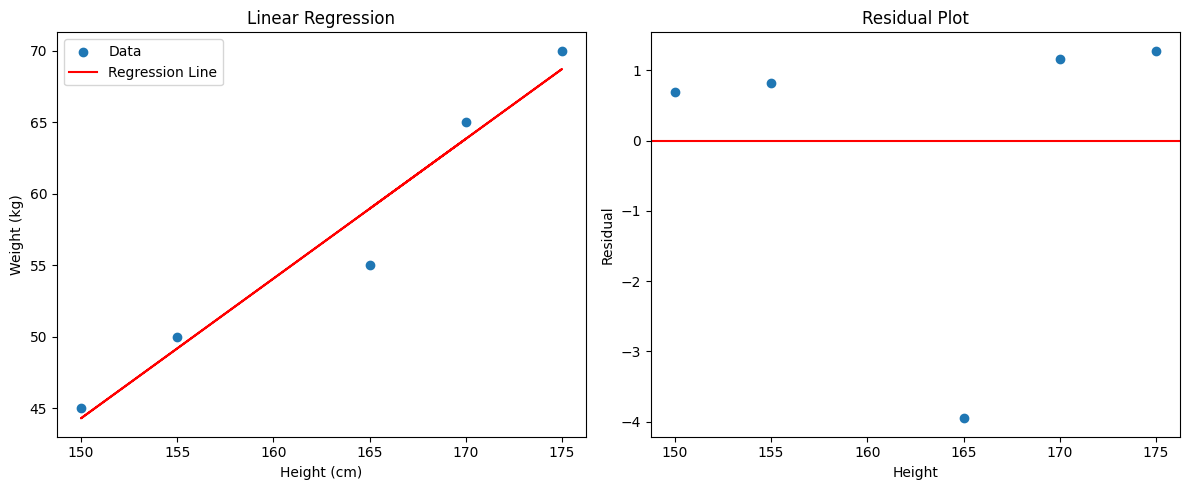


Logistic Regression model: sigmoid(0.4503*x1 + -0.2934*x2 + 0.0066)
Accuracy: 1.0


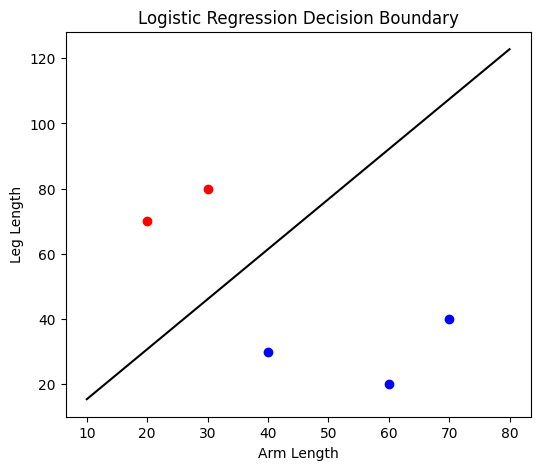

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp

# ============================
# 1. TRAINING DATA
# ============================
# Linear Regression: height → weight
lin_X = np.array([170, 155, 150, 175, 165])
lin_Y = np.array([65, 50, 45, 70, 55])

# Logistic Regression: arm, leg → gender (+1 / -1)
log_X = np.array([[40, 30],
                  [30, 80],
                  [20, 70],
                  [70, 40],
                  [60, 20]])
log_Y = np.array([1, -1, -1, 1, 1])


# ======================================================
# 2. LINEAR REGRESSION (Normal Equation – Pseudo inverse)
# ======================================================
A = np.column_stack([lin_X, np.ones(len(lin_X))])   # [[x,1],...]
At = A.T
AtA = At @ A
AtY = At @ lin_Y
W = np.linalg.inv(AtA) @ AtY

a, b = W[0], W[1]
print("Linear Regression: y = %.3f x + %.3f" % (a, b))


# ============================
# 3. Residuals
# ============================
pred_lin = a * lin_X + b
residuals = lin_Y - pred_lin


# ============================
# 4. Plot Linear Regression
# ============================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Scatter + regression line ---
axs[0].scatter(lin_X, lin_Y, label="Data")
axs[0].plot(lin_X, pred_lin, 'r', label="Regression Line")
axs[0].set_title("Linear Regression")
axs[0].set_xlabel("Height (cm)")
axs[0].set_ylabel("Weight (kg)")
axs[0].legend()

# --- Residual plot ---
axs[1].scatter(lin_X, residuals)
axs[1].axhline(0, color='r')
axs[1].set_title("Residual Plot")
axs[1].set_xlabel("Height")
axs[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


# ==============================================
# 5. LOGISTIC REGRESSION (gradient descent)
# ==============================================

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Convert labels { -1, +1 } → { 0, 1 }
log_Y_bin = (log_Y + 1) // 2

# Add bias
X_bias = np.column_stack([log_X, np.ones(len(log_X))])

W = np.zeros(3)   # W = [a, b, c]
lr = 0.001        # learning rate

# Train 20000 iterations
for i in range(20000):
    z = X_bias @ W
    p = sigmoid(z)
    grad = X_bias.T @ (p - log_Y_bin)
    W -= lr * grad

a2, b2, c2 = W
print("\nLogistic Regression model: sigmoid(%.4f*x1 + %.4f*x2 + %.4f)" % (a2, b2, c2))


# ============================
# 6. Accuracy
# ============================
p_pred = sigmoid(X_bias @ W)
y_pred = (p_pred >= 0.5).astype(int)
acc = np.mean(y_pred == log_Y_bin)
print("Accuracy:", acc)


# ============================
# 7. Plot Logistic Regression
# ============================
plt.figure(figsize=(6, 5))

for i in range(len(log_X)):
    color = 'blue' if log_Y[i] == 1 else 'red'
    plt.scatter(log_X[i][0], log_X[i][1], color=color)

# Decision boundary:
# a*x + b*y + c = 0  → y = -(a/b)x - c/b
xx = np.linspace(10, 80, 100)
yy = -(a2/b2) * xx - c2/b2
plt.plot(xx, yy, 'k')

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Arm Length")
plt.ylabel("Leg Length")
plt.show()